In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lucasturtle/national-anthems-of-the-world/anthems.csv


In [2]:
import matplotlib.pyplot as plt

# ****DataSet****

In [3]:
df = pd.read_csv('/kaggle/input/datasets/lucasturtle/national-anthems-of-the-world/anthems.csv')

df.shape

(190, 5)

In [4]:
df.columns

Index(['Country', 'Alpha-2', 'Alpha-3', 'Continent', 'Anthem'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Country    190 non-null    object
 1   Alpha-2    189 non-null    object
 2   Alpha-3    190 non-null    object
 3   Continent  190 non-null    object
 4   Anthem     190 non-null    object
dtypes: object(5)
memory usage: 7.6+ KB


In [6]:
df.isnull().sum()

Country      0
Alpha-2      1
Alpha-3      0
Continent    0
Anthem       0
dtype: int64

In [7]:
df['Continent'].value_counts()

Continent
Africa           56
Europe           44
Asia             44
North_America    24
South_America    12
Oceania          10
Name: count, dtype: int64

# ****EDA****

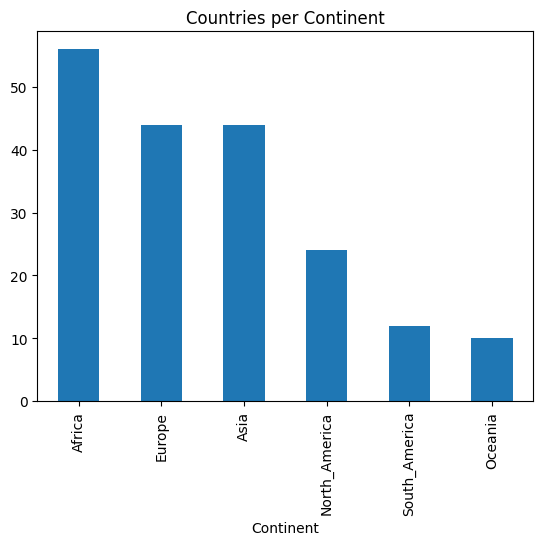

In [8]:
df["Continent"].value_counts().plot(kind="bar")
plt.title("Countries per Continent")
plt.show()

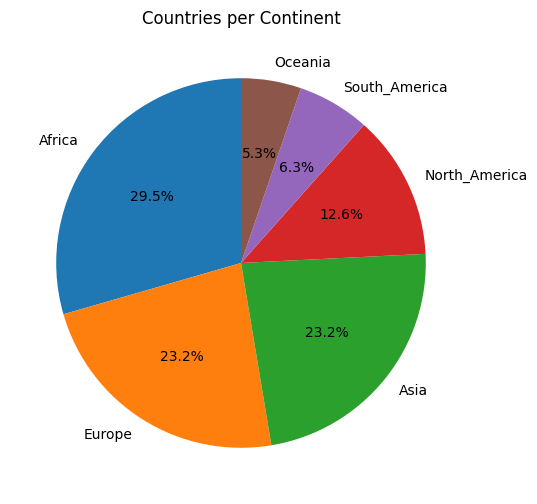

In [9]:
import matplotlib.pyplot as plt

df["Continent"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",   
    figsize=(6,6),
    startangle=90
)

plt.title("Countries per Continent")
plt.ylabel("")
plt.show()

In [10]:
df['Char_length'] = df['Anthem'].apply(len)
df["Word_count"] = df['Anthem'].apply(lambda x: len(x.split()))

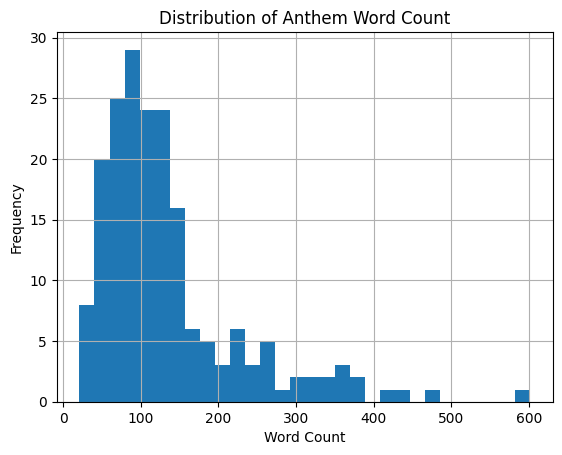

In [11]:
df["Word_count"].hist(bins=30)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Anthem Word Count")
plt.show()

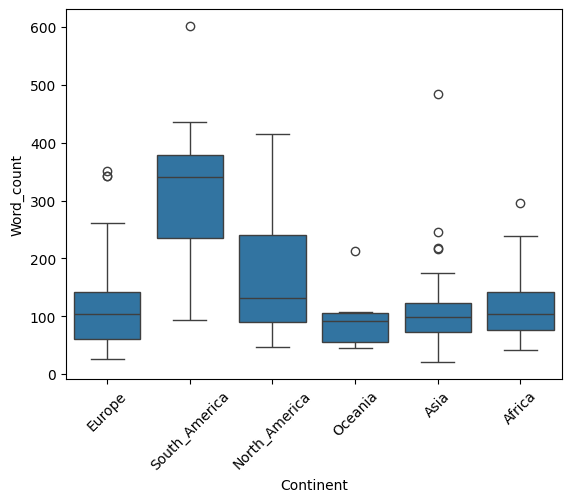

In [12]:
import seaborn as sns

sns.boxplot(x="Continent", y="Word_count", data=df)
plt.xticks(rotation=45)
plt.show()

In [13]:
df = df.drop(['Continent','Alpha-2'] , axis = 1)

In [14]:
df.rename(columns={"Alpha-3": "geo_code"}, inplace=True)

In [15]:
df.columns

Index(['Country', 'geo_code', 'Anthem', 'Char_length', 'Word_count'], dtype='object')

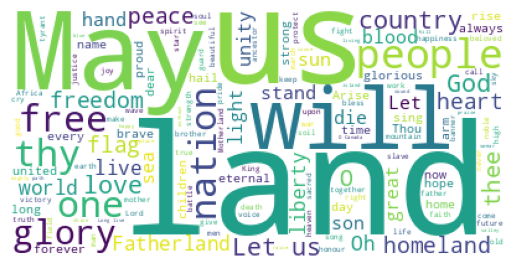

In [16]:
from wordcloud import WordCloud

wc = WordCloud(background_color="white").generate(
    " ".join(df["Anthem"])
)

plt.imshow(wc)
plt.axis("off")
plt.show()

# ******Preprocessing******

In [17]:
import string 

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lm = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
custom_words = {
    "thy","thee","thou","shall","may",
    "let","us","upon","o","ye"
}

stop_words = stop_words.union(custom_words)
exclude = string.punctuation

def standard_text(text):
    text = text.translate(str.maketrans('','',exclude))
    text = text.lower() 

    tokens = []
    for word in text.split():
        if word not in stop_words :
            lemma = lm.lemmatize(word)
            tokens.append(lemma)
    return " ".join(tokens).strip()
    

In [18]:
def clean_text(text):
    return text.lower()
    

In [19]:
df['Anthem'] = df['Anthem'].apply(clean_text)

In [20]:
df["Anthem_clean"]= df['Anthem'].apply(standard_text)

# ****Part A****

In [21]:
from collections import Counter 

all_words = " ".join(df['Anthem_clean']).split()
Counter(all_words).most_common(20)

[('land', 213),
 ('god', 133),
 ('people', 133),
 ('one', 108),
 ('free', 104),
 ('nation', 103),
 ('glory', 96),
 ('country', 94),
 ('freedom', 90),
 ('homeland', 89),
 ('love', 86),
 ('flag', 73),
 ('peace', 72),
 ('live', 70),
 ('heart', 69),
 ('fatherland', 65),
 ('oh', 64),
 ('great', 62),
 ('liberty', 62),
 ('long', 60)]

In [22]:
from sentence_transformers import SentenceTransformer 
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

In [23]:
model_l6 = SentenceTransformer('all-MiniLM-L6-v2')
model_l12 = SentenceTransformer('all-MiniLM-L12-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [24]:
embedding_l6 = model_l6.encode(df['Anthem'] , convert_to_tensor = False)
embedding_l12 = model_l12.encode(df['Anthem'] , convert_to_tensor = False)

In [25]:
similarity_matrix_l6 = cosine_similarity(embedding_l6)
similarity_matrix_l12 = cosine_similarity(embedding_l12)

In [26]:
df_l6 = pd.DataFrame(similarity_matrix_l6 ,index = df['Country'] ,columns =df['Country'])
df_l12 = pd.DataFrame(similarity_matrix_l12 ,index = df['Country'] ,columns =df['Country'])

print(df_l6.shape)
print(df_l12.shape)

print(df_l6)
print(df_l12)

(190, 190)
(190, 190)
Country          Albania   Armenia   Austria  Azerbaijan   Belarus   Belgium  \
Country                                                                        
Albania         1.000000  0.648774  0.326911    0.461295  0.492335  0.596004   
Armenia         0.648774  1.000000  0.362225    0.646338  0.512329  0.573865   
Austria         0.326911  0.362225  1.000000    0.453819  0.416828  0.452712   
Azerbaijan      0.461295  0.646338  0.453819    1.000000  0.575725  0.383476   
Belarus         0.492335  0.512329  0.416828    0.575725  1.000000  0.339370   
...                  ...       ...       ...         ...       ...       ...   
Tunisia         0.506765  0.407345  0.292687    0.396817  0.373124  0.366022   
Uganda          0.516893  0.500398  0.395365    0.350184  0.398287  0.544168   
Western Sahara  0.448919  0.399955  0.302731    0.454456  0.332795  0.338514   
Zambia          0.529082  0.545971  0.347976    0.387206  0.428191  0.493181   
Zimbabwe        0.

In [27]:
#Elbow Method

inertia = []
K_range = range(1,10)

for k in K_range :
    kmean = KMeans(n_clusters = k , random_state = 42)
    kmean.fit(embedding_l12)
    inertia.append(kmean.inertia_)

inertia

[109.96321105957031,
 105.470703125,
 101.82012939453125,
 99.11076354980469,
 98.07435607910156,
 95.98950958251953,
 94.71240234375,
 93.24253845214844,
 92.38174438476562]

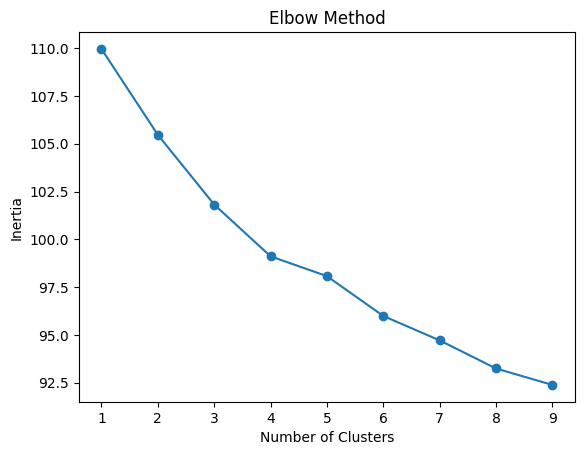

In [28]:
plt.plot(K_range,inertia,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [29]:
#Silhouette Score
from sklearn.metrics import silhouette_score

for k in range(2,10) :
    kmean = KMeans(n_clusters = k , random_state = 42)
    labels = kmean.fit_predict(embedding_l12)
    score = silhouette_score(embedding_l12 ,labels)
    print(k,'=>',score)

2 => 0.03981275
3 => 0.038242143
4 => 0.038644932
5 => 0.025430268
6 => 0.029915946
7 => 0.023247149
8 => 0.03736503
9 => 0.03659618


In [30]:
#KMeans 

kmean = KMeans(n_clusters = 4,random_state=42)

label = kmean.fit_predict(embedding_l12)

df["cluster"] = label 
df

,Country,geo_code,Anthem,Char_length,Word_count,Anthem_clean,cluster
0,Albania,ALB,"around our flag we stand united, with one wish...",794,146,around flag stand united one wish one goal sac...,0
1,Armenia,ARM,"our fatherland, free, independent, that has fo...",468,85,fatherland free independent century lived summ...,3
2,Austria,AUT,"land of mountains, land by the river, land of ...",613,99,land mountain land river land field land cathe...,2
3,Azerbaijan,AZE,"azerbaijan, azerbaijan! the glorious fatherlan...",818,138,azerbaijan azerbaijan glorious fatherland valo...,3
4,Belarus,BLR,"we, belarusians, are peaceful people, wholehea...",805,133,belarusian peaceful people wholeheartedly devo...,3
...,...,...,...,...,...,...,...
185,Tunisia,TUN,o defenders of the homeland! rally around to t...,751,139,defender homeland rally around glory time bloo...,0
186,Uganda,UGA,"oh uganda! may god uphold thee, we lay our fut...",402,73,oh uganda god uphold lay future hand united fr...,1
187,Western Sahara,ESH,"o sons of the sahara! in the battlefield, you ...",1099,205,son sahara battlefield torch holder long road ...,0
188,Zambia,ZMB,"stand and sing of zambia, proud and free, land...",684,128,stand sing zambia proud free land work joy uni...,1


In [31]:
df[df['Country'] == 'India']

,Country,geo_code,Anthem,Char_length,Word_count,Anthem_clean,cluster
97,India,IND,"thou art the ruler of the minds of all people,...",484,88,art ruler mind people dispenser india destiny ...,0


In [32]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

reduced = tsne.fit_transform(embedding_l12)

df["x"] = reduced[:, 0]
df["y"] = reduced[:, 1]

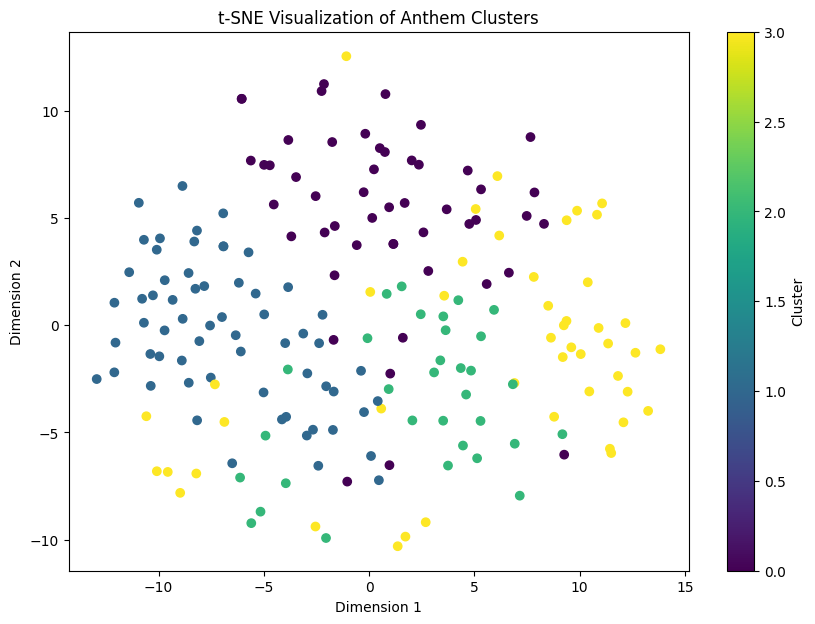

In [33]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["x"],
    df["y"],
    c=df["cluster"],
)

plt.title("t-SNE Visualization of Anthem Clusters")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.colorbar(label="Cluster")
plt.show()

In [34]:
from collections import Counter

for c in range(4):
    text = " ".join(df[df["cluster"]==c]["Anthem_clean"]).lower()
    words = text.split()
    print("\nCluster", c)
    print(Counter(words).most_common(15))


Cluster 0
[('glory', 45), ('free', 42), ('one', 40), ('homeland', 39), ('land', 33), ('people', 33), ('flag', 32), ('arm', 31), ('die', 31), ('god', 30), ('blood', 30), ('freedom', 30), ('light', 29), ('slave', 28), ('world', 26)]

Cluster 1
[('god', 72), ('land', 70), ('one', 48), ('people', 47), ('freedom', 38), ('nation', 38), ('bless', 33), ('free', 32), ('love', 32), ('peace', 31), ('country', 30), ('africa', 29), ('unity', 28), ('liberty', 26), ('ever', 26)]

Cluster 2
[('land', 67), ('homeland', 24), ('home', 20), ('canada', 20), ('heart', 19), ('god', 19), ('thousand', 19), ('love', 18), ('sea', 17), ('people', 16), ('dear', 16), ('stand', 15), ('great', 14), ('free', 14), ('guard', 14)]

Cluster 3
[('country', 45), ('land', 43), ('people', 37), ('nation', 31), ('glory', 27), ('flag', 26), ('long', 22), ('homeland', 22), ('freedom', 21), ('live', 21), ('great', 19), ('fatherland', 18), ('love', 18), ('world', 18), ('salute', 18)]


In [35]:
theme_map = {
    0: "War & Sacrifice",
    1: "Unity & People",
    2: "Geography & Homeland",
    3: "National Pride"
}

df["Theme"] = df["cluster"].map(theme_map)

In [36]:
import plotly.express as px

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="Theme",
    hover_name="Country",
    title="Semantic Themes of National Anthems"
)

fig.show()

In [61]:
world_map = px.choropleth(
    df,
    locations="geo_code",
    color="Theme",
    hover_name="Country",
    title="Global Clustering of National Anthems",
)

world_map.show()

#   0: "War & Sacrifice",
#   1: "Unity & People",
#   2: "Geography & Homeland",
#   3: "National Pride"

# ****Part B****

In [38]:
pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.0 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.


In [39]:
from bertopic import BERTopic
from hdbscan import HDBSCAN
from sklearn.cluster import KMeans

topic_model = BERTopic(
    hdbscan_model=KMeans(n_clusters=4, random_state=42)
)

topics, probs = topic_model.fit_transform(df["Anthem"])

2026-03-03 09:25:57.602359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772529957.879998      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772529957.955193      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772529958.612977      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772529958.613036      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772529958.613040      55 computation_placer.cc:177] computation placer alr

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [40]:
df['Topic'] = topics

In [41]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,65,0_and_of_our_the,"[and, of, our, the, we, to, us, in, all, let]",[against the humiliating bondage of a thousand...
1,1,51,1_the_of_and_our,"[the, of, and, our, in, land, to, your, thy, for]","[o lord, bless the nation of hungary with your..."
2,2,42,2_the_of_our_and,"[the, of, our, and, my, for, is, are, country,...",[i am ready to give life for our native hearth...
3,3,32,3_the_and_of_to,"[the, and, of, to, in, we, that, your, its, is]","[beloved homeland, receive the vows that chile..."


In [42]:
topic_model.visualize_topics()

In [43]:
topic_model.visualize_barchart()

In [44]:
from collections import Counter

for c in range(4):
    text = " ".join(df[df["Topic"]==c]["Anthem_clean"]).lower()
    words = text.split()
    print("\nTopic", c)
    print(Counter(words).most_common(15))


Topic 0
[('land', 67), ('people', 53), ('god', 49), ('one', 49), ('nation', 38), ('free', 34), ('freedom', 32), ('heart', 31), ('bless', 30), ('unity', 30), ('country', 29), ('peace', 29), ('sing', 28), ('love', 27), ('africa', 27)]

Topic 1
[('land', 82), ('god', 50), ('love', 38), ('homeland', 27), ('sea', 27), ('great', 22), ('mother', 22), ('people', 21), ('free', 21), ('son', 20), ('beloved', 20), ('thousand', 20), ('canada', 20), ('heart', 19), ('stand', 19)]

Topic 2
[('country', 47), ('land', 33), ('flag', 31), ('homeland', 30), ('people', 28), ('glory', 28), ('nation', 23), ('world', 20), ('god', 20), ('live', 19), ('long', 19), ('freedom', 17), ('one', 15), ('free', 14), ('love', 14)]

Topic 3
[('glory', 45), ('free', 35), ('die', 35), ('one', 33), ('fatherland', 31), ('land', 31), ('freedom', 31), ('people', 31), ('arm', 30), ('liberty', 28), ('homeland', 27), ('nation', 26), ('slave', 26), ('blood', 23), ('flag', 22)]


In [45]:
theme_map_bertopic = {
    0: "Patriotism & National Unity",
    1: "National Identity & Homeland",
    2: "Freedom & National Glory",
    3: "Defense & National Strength"
}

df["Theme_bertopic"] = df["Topic"].map(theme_map_bertopic)

In [46]:
color_map = {
    "Patriotism & National Unity": "orange",   # energy, unity
    "National Identity & Homeland": "blue",    # stability, belonging
    "Freedom & National Glory": "green",        # victory, honor,liberty symbolism
    "Defense & National Strength": "red"       # power, sacrifice
}

In [47]:
import plotly.express as px

fig_bertopic = px.scatter(
    df,
    x="x",
    y="y",
    color="Theme_bertopic",
    color_discrete_map = color_map,
    hover_name="Country",
    title="Semantic Themes of National Anthems"
)

fig_bertopic.show()

In [48]:
# df_clean = df[df["Topic"] != -1]

# fig_clean_bertopic = px.scatter(
#     df_clean,
#     x="x",
#     y="y",
#     color="Theme_bertopic",
#     color_discrete_map=color_map,
#     hover_name="Country",
#     title="Anthem Themes (Outliers Removed)"
# )

# fig_clean_bertopic.update_traces(marker=dict(size=9, opacity=0.75))
# fig_clean_bertopic.show()

In [49]:
world_map_bertopic = px.choropleth(
    df,
    locations="geo_code",
    color="Theme_bertopic",
    color_discrete_map=color_map,
    hover_name="Country",
    title="Global Clustering of National Anthems",
)

world_map_bertopic.show()

# ****Prediction Model****

In [50]:
topic_embeddings = topic_model.topic_embeddings_

def show_prediction(text):

    #####Kmeans########
    
    # Generate embedding
    embedding = model_l12.encode([text])

    # Predict cluster
    cluster = kmean.predict(embedding)[0]

    # Find most similar country
    similarities = cosine_similarity(
        embedding,
        embedding_l12
    )

    idx = np.argmax(similarities)

    similar_country = df.iloc[idx]["Country"]
    similarity_score = similarities[0][idx]

    # Cluster → Theme mapping
    theme_map_cluster = {
    0: "War & Sacrifice",
    1: "Unity & People",
    2: "Geography & Homeland",
    3: "National Pride"
    }

    theme_cluster = theme_map_cluster.get(cluster)

    #######Bertopic######
    
    # Generate embedding
    embedding = model_l12.encode([text])

    # Find closest topic
    topic_sim = cosine_similarity(
        embedding,
        topic_embeddings
    )

    topic_id = np.argmax(topic_sim)
    confidence = topic_sim[0][topic_id]

    # Topic → Theme mapping
    theme_map = {
        0: "Patriotism & National Unity",
        1: "National Identity & Homeland",
        2: "Freedom & National Glory",
        3: "Defense & National Strength"
    }

    theme = theme_map.get(topic_id, "Mixed / Other")

     #####Visualization######
    
    print("\n" + "="*60)
    print("NATIONAL ANTHEM SEMANTIC ANALYSIS")
    print("="*60)

    print("\n")
    print("-"*60)
    print("KMeans Semantic Cluster")
    print("-"*60)
    print(f"Cluster              : {theme_cluster}")
    print(f"Most Similar Country : {similar_country}")
    print(f"Similarity Score     : {similarity_score:.3f}")

    print("\n ")
    print("-"*60)
    print("BERTopic Theme Detection")
    print("-"*60)
    print(f"Theme      : {theme}")
    print(f"Confidence : {confidence:.3f}")

    print("\n" + "="*60)
   

In [51]:
anthem_text = """
Our nation rises with courage,
our people defend the land with pride.
"""

show_prediction(anthem_text)


NATIONAL ANTHEM SEMANTIC ANALYSIS


------------------------------------------------------------
KMeans Semantic Cluster
------------------------------------------------------------
Cluster              : National Pride
Most Similar Country : Albania
Similarity Score     : 0.622

 
------------------------------------------------------------
BERTopic Theme Detection
------------------------------------------------------------
Theme      : Patriotism & National Unity
Confidence : 0.497



In [52]:
india_Anthem = df[df['Country']=='India']['Anthem'].iloc[0]

In [53]:
india_Anthem

"thou art the ruler of the minds of all people, dispenser of india's destiny. thy name rouses the hearts of punjab, sindh,  gujarat and maratha, of the dravida and odisha and bengal; it echoes in the hills of vindhya and the himalayas, mingles in the music of ganga and yamuna and is chanted by the waves of the indian sea. they pray for thy blessings and sing thy praise. the saving of all people waits in thy hand, thou dispenser of india's destiny. victory, victory, victory to thee"

In [54]:
show_prediction(india_Anthem)


NATIONAL ANTHEM SEMANTIC ANALYSIS


------------------------------------------------------------
KMeans Semantic Cluster
------------------------------------------------------------
Cluster              : War & Sacrifice
Most Similar Country : India
Similarity Score     : 1.000

 
------------------------------------------------------------
BERTopic Theme Detection
------------------------------------------------------------
Theme      : National Identity & Homeland
Confidence : 0.414



In [55]:
show_prediction("With hearts full of patriotism, citizens come together to celebrate national unity and collective strength.")


NATIONAL ANTHEM SEMANTIC ANALYSIS


------------------------------------------------------------
KMeans Semantic Cluster
------------------------------------------------------------
Cluster              : National Pride
Most Similar Country : Sao Tome and Principe
Similarity Score     : 0.552

 
------------------------------------------------------------
BERTopic Theme Detection
------------------------------------------------------------
Theme      : Patriotism & National Unity
Confidence : 0.446



In [56]:
show_prediction("Brave warriors defend the nation and sacrifice their lives to protect the country’s strength.")


NATIONAL ANTHEM SEMANTIC ANALYSIS


------------------------------------------------------------
KMeans Semantic Cluster
------------------------------------------------------------
Cluster              : War & Sacrifice
Most Similar Country : Tunisia
Similarity Score     : 0.561

 
------------------------------------------------------------
BERTopic Theme Detection
------------------------------------------------------------
Theme      : Defense & National Strength
Confidence : 0.412



In [57]:
show_prediction("Freedom and liberty shine across the land as the nation celebrates its glorious independence.")


NATIONAL ANTHEM SEMANTIC ANALYSIS


------------------------------------------------------------
KMeans Semantic Cluster
------------------------------------------------------------
Cluster              : National Pride
Most Similar Country : Georgia
Similarity Score     : 0.600

 
------------------------------------------------------------
BERTopic Theme Detection
------------------------------------------------------------
Theme      : Patriotism & National Unity
Confidence : 0.413



In [58]:
show_prediction("This homeland represents our cultural identity and national heritage passed from generation to generation.")


NATIONAL ANTHEM SEMANTIC ANALYSIS


------------------------------------------------------------
KMeans Semantic Cluster
------------------------------------------------------------
Cluster              : National Pride
Most Similar Country : Turkmenistan
Similarity Score     : 0.613

 
------------------------------------------------------------
BERTopic Theme Detection
------------------------------------------------------------
Theme      : Freedom & National Glory
Confidence : 0.466

